# Forest Fire Data Analysis

This notebook analyzes forest fire data using machine learning to predict fire occurrence and understand key risk factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Load and Explore the Dataset

We'll use the UCI Forest Fires dataset from Portugal.

In [2]:
# Load the forest fires dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/forest-fires/forestfires.csv'
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (517, 13)

First few rows:


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [3]:
# Dataset information
print("Dataset Info:")
print(df.info())
print("\nDataset Description:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None

Dataset Description:


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


## 2. Data Preprocessing

Create binary classification target: fire occurred (area > 0) or not.

In [5]:
# Create binary target variable
df['fire_occurred'] = (df['area'] > 0).astype(int)

# Encode categorical variables
df['month'] = pd.Categorical(df['month'], categories=['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']).codes
df['day'] = pd.Categorical(df['day'], categories=['mon','tue','wed','thu','fri','sat','sun']).codes

print(f"Fire occurrence distribution:")
print(df['fire_occurred'].value_counts())
print(f"\nPercentage of fires: {df['fire_occurred'].mean()*100:.2f}%")

Fire occurrence distribution:
fire_occurred
1    270
0    247
Name: count, dtype: int64

Percentage of fires: 52.22%


## 3. Exploratory Data Analysis

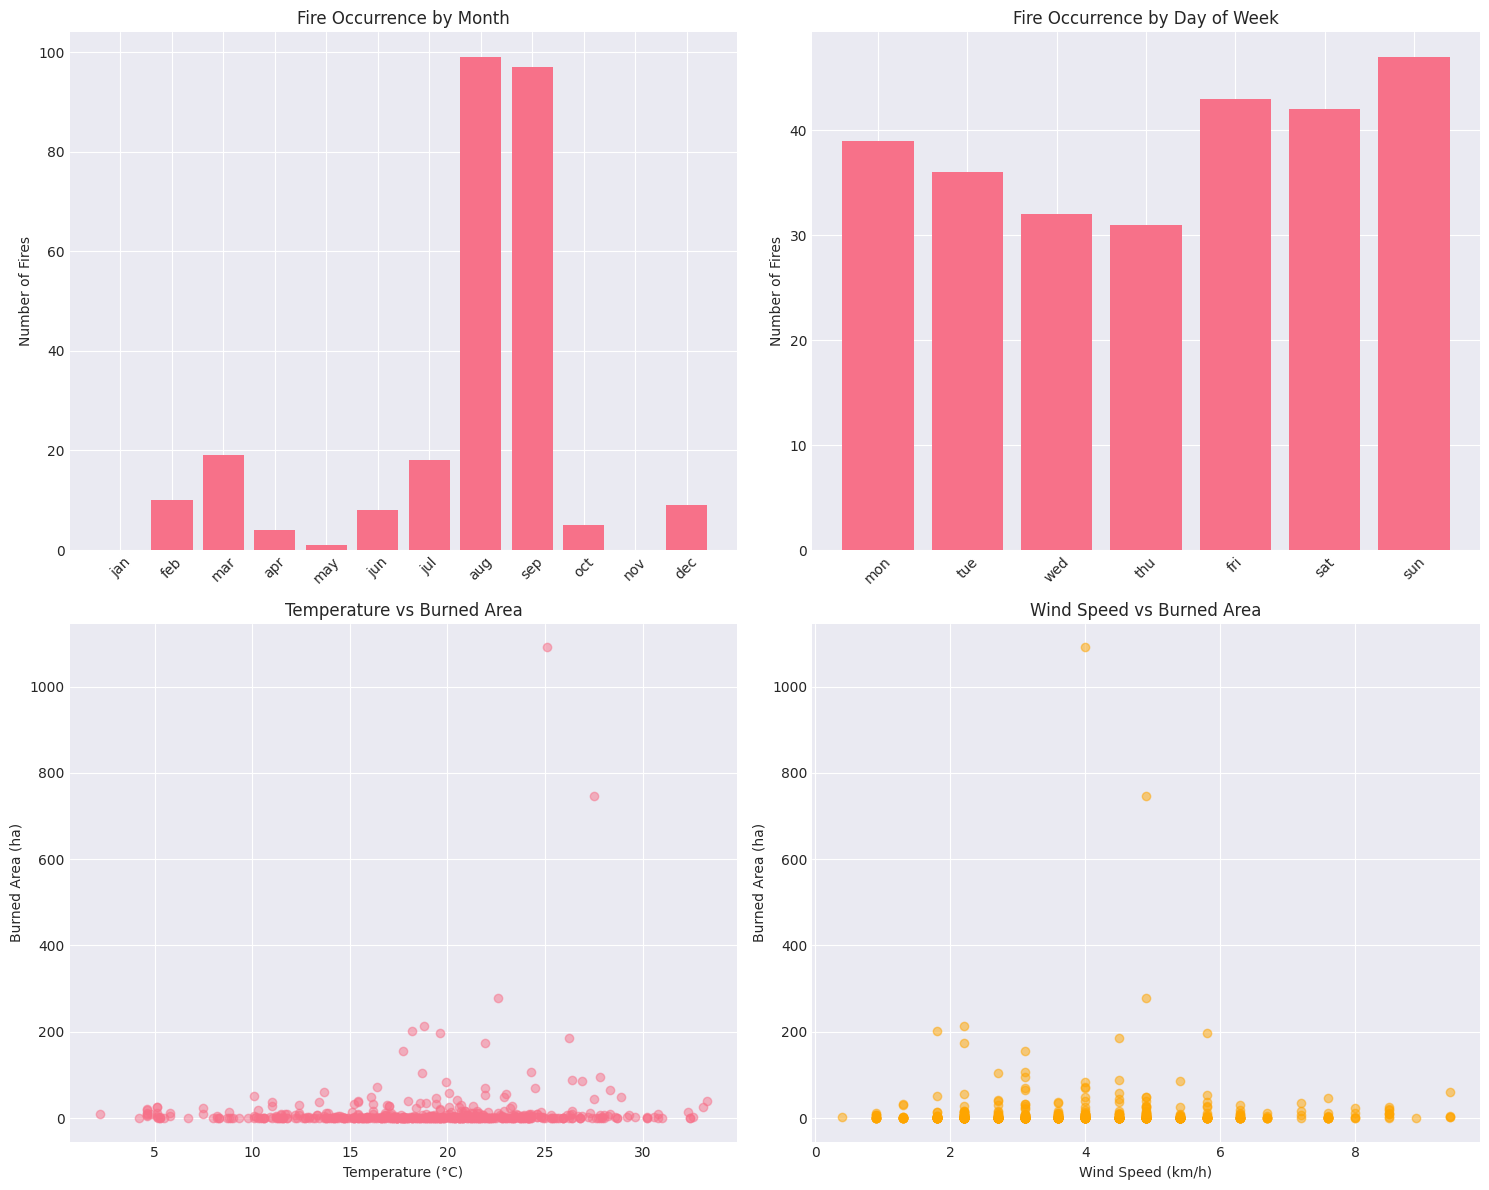

In [6]:
# Fire occurrence by month
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Month distribution
month_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_fire = df.groupby('month')['fire_occurred'].agg(['sum', 'count'])
axes[0, 0].bar(range(12), month_fire['sum'])
axes[0, 0].set_xticks(range(12))
axes[0, 0].set_xticklabels(month_names, rotation=45)
axes[0, 0].set_title('Fire Occurrence by Month')
axes[0, 0].set_ylabel('Number of Fires')

# Day distribution
day_names = ['mon','tue','wed','thu','fri','sat','sun']
day_fire = df.groupby('day')['fire_occurred'].agg(['sum', 'count'])
axes[0, 1].bar(range(7), day_fire['sum'])
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names, rotation=45)
axes[0, 1].set_title('Fire Occurrence by Day of Week')
axes[0, 1].set_ylabel('Number of Fires')

# Temperature vs Fire
axes[1, 0].scatter(df['temp'], df['area'], alpha=0.5)
axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Burned Area (ha)')
axes[1, 0].set_title('Temperature vs Burned Area')

# Wind vs Fire
axes[1, 1].scatter(df['wind'], df['area'], alpha=0.5, color='orange')
axes[1, 1].set_xlabel('Wind Speed (km/h)')
axes[1, 1].set_ylabel('Burned Area (ha)')
axes[1, 1].set_title('Wind Speed vs Burned Area')

plt.tight_layout()
plt.show()

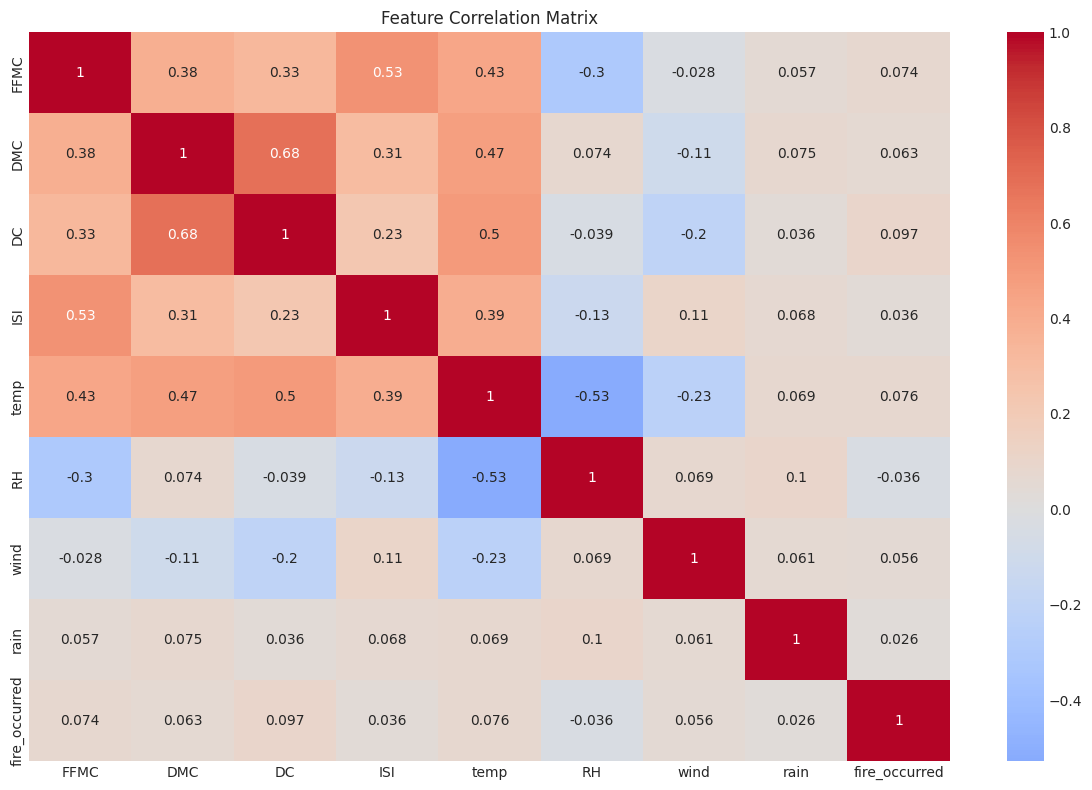

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'fire_occurred']
sns.heatmap(df[correlation_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Machine Learning Model

Train a Random Forest Classifier to predict fire occurrence based on weather conditions.

In [8]:
# Prepare features and target
feature_cols = ['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
X = df[feature_cols]
y = df['fire_occurred']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (413, 12)
Test set size: (104, 12)


In [9]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=5)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluate model
print("Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Fire', 'Fire']))

Model Performance:
Accuracy: 0.644

Classification Report:
              precision    recall  f1-score   support

     No Fire       0.64      0.60      0.62        50
        Fire       0.65      0.69      0.67        54

    accuracy                           0.64       104
   macro avg       0.64      0.64      0.64       104
weighted avg       0.64      0.64      0.64       104



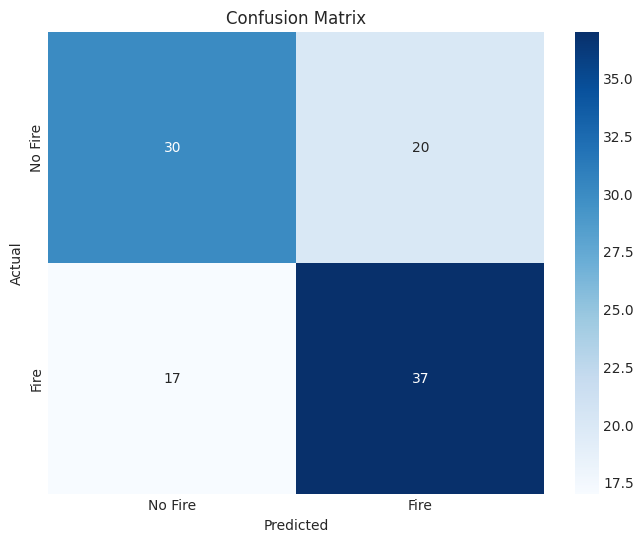

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 5. Feature Importance Analysis

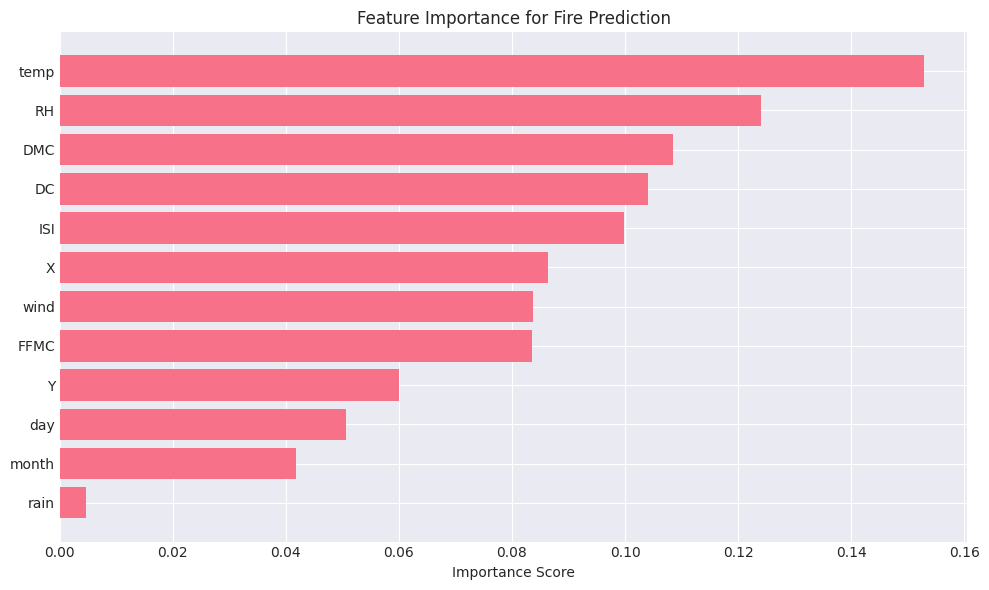


Top 5 Most Important Features:
  feature  importance
8    temp    0.152918
9      RH    0.124131
5     DMC    0.108430
6      DC    0.104113
7     ISI    0.099876


In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance for Fire Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

## 6. Key Insights

**Summary of Analysis:**

1. **Seasonal Patterns**: Forest fires show seasonal trends, with higher occurrence in certain months
2. **Weather Impact**: Temperature, humidity, and wind speed are significant predictors
3. **Fire Indices**: FFMC, DMC, DC, and ISI (fire weather indices) provide valuable predictive power
4. **Model Performance**: Random Forest achieves reasonable accuracy in predicting fire occurrence
5. **Risk Factors**: The most important features help identify high-risk conditions for fire prevention